# 01_find_tcp

This notebook demonstrates how the temperature calibration plates (TCPs) were detected. As with the other notebooks, the workflow is shown only on a subset of the data; the process can be scaled up to the entire dataset.

In [1]:
import os
import pandas as pd
import rasterio as rio
#from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

In [2]:
from modules.tcp import *
from modules.utils import load_flight_window

In this configuration cell, we define I/O paths. We also hardcode `WATER_VECTORS` and the specific IDs of the TCPs, as we deployed five out of six TCPs during the flight campaign on 22 June.

`WATER_VECTORS` have their origin at the centre of the detected TCP (this is enabled by choosing the template matching approach) and end at the approximate position where the PT100 was placed in the water. This allows extraction of the pixels in the proximity of the sensor.

In [3]:
DATE = "20250807"
ROOT_PATH = "data/h20t/images"
TCP_IMG_PATH = "data/h20t"
OUT_DIR = "results/01_find_tcp"
os.makedirs(OUT_DIR, exist_ok=True)
FIG_DIR = OUT_DIR #/ "tcp_figs" #commented out for demo purposes
os.makedirs(FIG_DIR, exist_ok=True)
WATER_VECTORS = {
    "20250622": {"tcp4": np.array([23, 53]),
                 "tcp5": np.array([-31, 52])},
    "20250807": {"tcp3": np.array([41, -39]),
                 "tcp5": np.array([-10, -32])},
    "20250813": {"tcp3": np.array([38, -46]),
                 "tcp5": np.array([-10, -32])},
    "20250814": {"tcp3": np.array([ 38, -46]),
                 "tcp5": np.array([-10, -32])}}

flight_start, flight_end = load_flight_window(DATE)
print(f"Flight window: {flight_start} – {flight_end}")

if DATE == "20250622":
    tcp_list = ["tcp1", "tcp2", "tcp4", "tcp5", "tcp6"]
else:
    tcp_list = ["tcp1", "tcp2", "tcp3", "tcp4", "tcp5", "tcp6"]

water_vectors = WATER_VECTORS[DATE]
print(f"TCPs measuring water temperature: {water_vectors.keys()}")

Flight window: 2025-08-07 13:43:45 – 2025-08-07 14:01:43
TCPs measuring water temperature: dict_keys(['tcp3', 'tcp5'])


Fetch TCP 3, its reference image and one of the images where the TCP appears. TODO: add scripts used to find the images where the TCP appeared

In [4]:
demo_tcp = "tcp3"
demo_dir = f"{TCP_IMG_PATH}/{demo_tcp}"
fnames = sorted(os.listdir(demo_dir))
ref_img = fnames[-1]
demo_img = fnames[4]

print(f"TCP: {demo_tcp}")

TCP: tcp3


Show how the reference image is matched to a pattern in the demo image. TODO: add equation and explanation.

The detected pixels are then used to extract the temperature from the flight images, which are already in °C.

In [5]:
# This is where regconv shines
erosion, m, n, cx, cy, = find_tcp(f"{demo_dir}/{demo_img}", f"{demo_dir}/{ref_img}")

#Load thermal TIFf
tname = demo_img.split(".")[0] + ".tiff"
with rio.open(f"{ROOT_PATH}/{tname}") as src:
    timg = src.read(1).astype("float32")

plate_temp = extract_plate_temperature(timg, cx, cy)
print(f"Extracted median plate temperature: {plate_temp:.2f} °C")

vector = None
if demo_tcp in water_vectors.keys(): #tcps with water
    water_t, vector = finding_dory(timg, cx, cy, water_vectors[demo_tcp])
    print(f"Extracted water temperature: {water_t:.2f} °C")

Extracted median plate temperature: 42.25 °C
Extracted water temperature: 9.60 °C


Show the detected TCP regions from which the radiometric temperature is extracted.

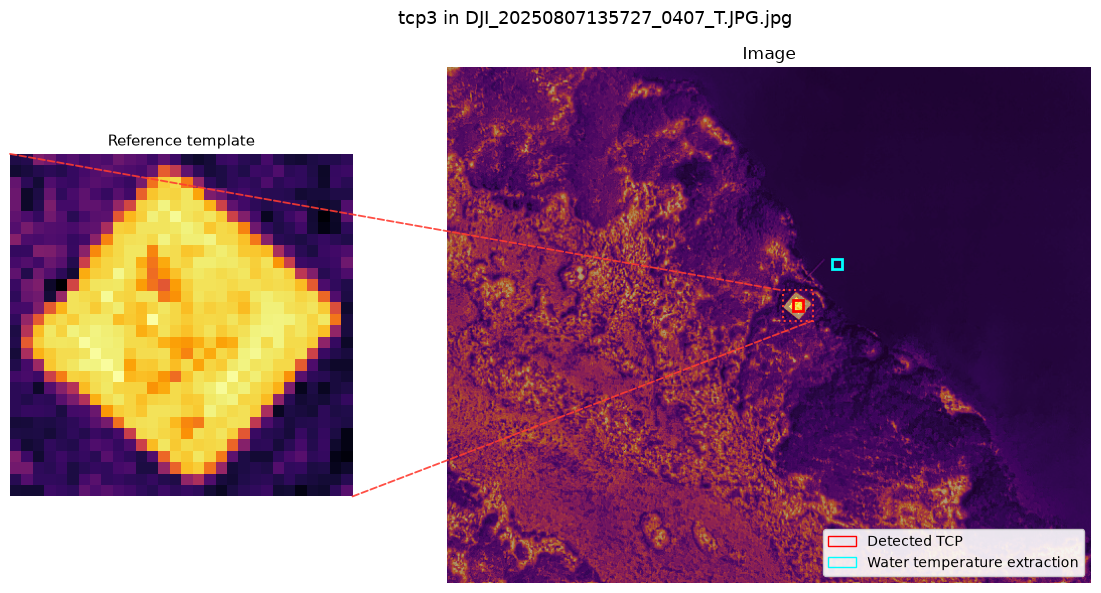

In [6]:
img_gray = cv.imread(str(f"{demo_dir}/{demo_img}"), cv.IMREAD_GRAYSCALE)
ref_gray = cv.imread(str(f"{demo_dir}/{ref_img}"), cv.IMREAD_GRAYSCALE)

fig = plot_template_match(
    img_gray, ref_gray, erosion, m, n, cx, cy,
    water_vector=vector,
    title=f"{demo_tcp} in {demo_img}")

fig.savefig(f"{FIG_DIR}/{DATE}_demo_detected_tcp.png",
             dpi=150, bbox_inches="tight")

Et voilà, this process can be scaled up to entire flights to build a dataframe containing the temperature medians of the detected TCP regions.

These image temperature medians then need to be matched with the skin temperature extracted from the PT100 sensors. The cells below are not meant to be executed in the demo, but you can take a look at how this dataframe, pairing the skin and radiometric temperatures for each TCP, was built.

During template matching, outliers can appear. When extracting the median from the distribution of pixels within a detected TCP region, it is reasonable to expect a homogeneous region given the surfaces used. We therefore apply a further condition: if the standard deviation of the extracted TCP region exceeds 2 °C, the TCP is rejected. This approach was used in the thesis. TODO: add literature

With these conditions applied, the cell below outputs the TCP dataframe for each flight campaign to the `{YYYYMMDD}_calibration_df.parquet` files. These files are included in the `./data/ancillary` directory to show the processing in the following notebooks. Our focus will be, however, on 7 Aug.

# Build calibration dataframe (not to be executed)

In [ ]:
EXIFTOOL = str("tools/exiftool.exe")

OUT_DIR = Path("D:/dancejod/dt/data")
FIG_DIR = OUT_DIR / "tcp_figs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

tcp_counts = {}
for date in ["20250622", "20250807", "20250813", "20250814"]:
    print(date)
    ROOT_PATH = Path(f"D:/dancejod/dp_data/to_dp/{date}/h20t/calibrated/images")
    TCP_IMG_PATH = Path(f"D:/dancejod/dp_data/to_dp/{date}/h20t")
    flight_start, flight_end = load_flight_window(date)
    print(f"Flight window: {flight_start} - {flight_end}")
    tcp_list = (["tcp1","tcp2","tcp4","tcp5","tcp6"] if date == "20250622" else ["tcp1","tcp2","tcp3","tcp4","tcp5","tcp6"])
    water_vectors = WATER_VECTORS[date]

    pt100 = {}
    for tcp in tcp_list:
        df_p = pd.read_parquet(OUT_DIR / "tcp" / f"{date}ur_{tcp[-1]}.parquet").reset_index()
        pt100[tcp] = df_p.loc[(df_p.timestamp >= flight_start) & (df_p.timestamp <= flight_end)]

    records = []
    n_kept = 0
    n_excl_std = 0
    n_nodet = 0

    for tcp in tcp_list:
        print(f"{date}: Processing {tcp}...")
        tcp_dir = TCP_IMG_PATH / tcp
        fnames = sorted(os.listdir(tcp_dir))
        ref_img = fnames[-1]
        for fname in fnames[:-1]:
            capture_time = pd.to_datetime(fname.split("_")[1], format="%Y%m%d%H%M%S")
            capture_minute = capture_time.replace(second=0)
            erosion, m, n, cx, cy = find_tcp(tcp_dir / fname, tcp_dir / ref_img)
            if erosion is None:
                print(f"{fname}: no TCP detected")
                n_nodet += 1
                continue

            with rio.open(ROOT_PATH / (fname.split(".")[0] + ".tiff")) as src:
                timg = src.read(1).astype("float32")

            plate_temp = extract_plate_temperature(timg, cx, cy)
            _, surf_std, n_px = plate_stats(timg, erosion, m, n)

            if not np.isfinite(surf_std) or surf_std > 2:
                print(f"EXCLUDE plate {fname}: surf_std={surf_std:.2f} > {2}")
                n_excl_std += 1
            
            else:
                records.append({"timestamp": capture_minute, "timestamp_seconds": capture_time,
                                "tcp_label": tcp, "tcp_name": f"{tcp}_plate",
                                "img_temperature": plate_temp, "surf_std": surf_std, "n_px": n_px,})
                n_kept += 1

            if tcp in water_vectors:
                water_temp, wvec = finding_dory(timg, cx, cy, water_vectors[tcp])
                _, w_std, w_px = water_stats(timg, cx, cy, wvec)
                if not np.isfinite(w_std) or w_std > 2:
                    print(f"EXCLUDE water {fname}: surf_std={w_std:.2f} > {2}")
                    n_excl_std += 1

                else:
                    records.append({"timestamp": capture_minute, "timestamp_seconds": capture_time,
                                    "tcp_label": tcp, "tcp_name": f"{tcp}_water",
                                    "img_temperature": water_temp, "surf_std": w_std, "n_px": w_px,})
                    n_kept += 1

    tcp_counts[date] = {"kept": n_kept, "excl_std": n_excl_std, "no_detection": n_nodet}
    print(f"Done {date}: kept {n_kept}, excl(std) {n_excl_std}, no-det {n_nodet}")

    tcp_df = pd.DataFrame(records)
    parts = []
    for tcp, df_p in pt100.items():
        sub = tcp_df[tcp_df.tcp_label == tcp]
        p = sub.merge(df_p[["timestamp", "temp1", "temp2"]], on="timestamp", how="inner")
        parts.append(p)

    df_all = pd.concat(parts).drop(columns=["tcp_label"])
    df_all["pt100_temperature"] = np.where(df_all["tcp_name"].str.endswith("plate"), df_all["temp1"], df_all["temp2"])
    df_all["temperature_diff"] = df_all["pt100_temperature"] - df_all["img_temperature"]
    df_all.drop(columns=["temp1", "temp2"], inplace=True)

    out_path = OUT_DIR / f"{date}_calibration_df.parquet"
    df_all.to_parquet(out_path)
    df_all.to_csv(out_path.with_suffix(".csv"), index=False)
    print(f"Saved {out_path} and .csv  ({len(df_all)} rows")

print("Summary:", tcp_counts)

## Figures

Claude was prompted here to refactor and visualise the process above and produce the figure shown in the thesis.

In [ ]:
SURF_STD_LIMIT = 2
def _plate_pixels(timg, erosion, m, n):
    """Thermal pixel values inside the eroded plate mask (should match plate_stats)."""
    eh, ew = erosion.shape[:2]
    crop = timg[m:m+eh, n:n+ew]
    mask = np.asarray(erosion) > 0
    vals = crop[mask].astype("float32")
    return vals[np.isfinite(vals)]


def build_qc_example(date, tcp, fname, accent):
    TCP_IMG_PATH = Path(f"D:/dancejod/dp_data/to_dp/{date}/h20t")
    ROOT_PATH    = Path(f"D:/dancejod/dp_data/to_dp/{date}/h20t/calibrated/images")
    tcp_dir = TCP_IMG_PATH / tcp
    ref_img = sorted(os.listdir(tcp_dir))[-1]

    erosion, m, n, cx, cy = find_tcp(tcp_dir / fname, tcp_dir / ref_img)
    if erosion is None:
        raise ValueError(f"No TCP detected in {fname}")
    with rio.open(ROOT_PATH / (fname.split(".")[0] + ".tiff")) as src:
        timg = src.read(1).astype("float32")

    pix = _plate_pixels(timg, erosion, m, n)
    img_gray = cv.imread(str(tcp_dir / fname), cv.IMREAD_GRAYSCALE)
    return {"img_gray": img_gray, "erosion": erosion, "m": m, "n": n, "cx": cx, "cy": cy,
            "pixels": pix, "std": float(np.std(pix)), "mean": float(np.mean(pix)),
            "tcp": tcp, "fname": fname, "accent": accent}


def find_good_example(date, tcp, limit=SURF_STD_LIMIT):
    """First detected image on this TCP that sits comfortably under the std limit."""
    TCP_IMG_PATH = Path(f"D:/dancejod/dp_data/to_dp/{date}/h20t")
    ROOT_PATH    = Path(f"D:/dancejod/dp_data/to_dp/{date}/h20t/calibrated/images")
    tcp_dir = TCP_IMG_PATH / tcp
    fnames = sorted(os.listdir(tcp_dir)); ref = fnames[-1]
    for fname in fnames[:-1]:
        erosion, m, n, cx, cy = find_tcp(tcp_dir / fname, tcp_dir / ref)
        if erosion is None:
            continue
        tiff = ROOT_PATH / (fname.split(".")[0] + ".tiff")
        if not tiff.exists():
            continue
        with rio.open(tiff) as src:
            timg = src.read(1).astype("float32")
        pix = _plate_pixels(timg, erosion, m, n)
        if pix.size and np.std(pix) <= limit * 0.5:
            return fname
    return None

def plot_std_qc(good, bad, std_limit=SURF_STD_LIMIT, title=None,
                c_keep="#2e9e5b", c_excl="#d64545"):
    fig = plt.figure(figsize=(12, 9), constrained_layout=True)
    gs = fig.add_gridspec(2, 2, height_ratios=[1.45, 1], hspace=0, wspace=0.18)

    # ---- top row: detections ----
    for col, ex, accent, tag in [(0, good, c_keep, ""),
                                 (1, bad, c_excl, "")]:
        ax_img = fig.add_subplot(gs[0, col])
        plot_detected_tcp(ex["img_gray"], ex["erosion"], ex["m"], ex["n"],
                          ex["cx"], ex["cy"], ax=ax_img, title="")
        ax_img.set_title(f"{tag} {ex['tcp']} {ex['fname'].split('_')[1]}",
                         color=accent, fontsize=11, fontweight="bold")
        ax_img.add_patch(mpatches.Rectangle((0, 0), 1, 1, transform=ax_img.transAxes,
                         fill=False, edgecolor=accent, lw=3, clip_on=False))
        ax_img.text(0.02, 0.98, f"σ = {ex['std']:.2f} °C",
                    transform=ax_img.transAxes, va="top", ha="left", fontsize=11,
                    fontweight="bold", color="white",
                    bbox={"facecolor": accent, "alpha": 0.85, "pad": 3, "edgecolor": "none"})

    # ---- bottom row: pixel distributions (deviation from mean, shared x) ----
    dev_good = good["pixels"] - good["mean"]
    dev_bad  = bad["pixels"]  - bad["mean"]
    span = np.percentile(np.abs(np.concatenate([dev_good, dev_bad])), 99.5)
    span = max(span, std_limit * 1.5) * 1.05
    bins = np.linspace(-span, span, 41)

    for col, dev, ex, accent, tag in [(0, dev_good, good, c_keep, ""),
                                      (1, dev_bad, bad, c_excl, "")]:
        ax_h = fig.add_subplot(gs[1, col])
        ax_h.hist(dev, bins=bins, color=accent, alpha=0.8,
                  edgecolor="white", linewidth=0.4)
        ax_h.axvline(ex["std"],  color=accent, ls="--", lw=1.3)
        ax_h.axvline(-ex["std"], color=accent, ls="--", lw=1.3,
                     label=f"±1σ = ±{ex['std']:.2f} °C")
        ax_h.set_xlim(-span, span)
        ax_h.set_xlabel("Diff from mean plate temperature [°C]")
        if col == 0:
            ax_h.set_ylabel("Pixel count")
        cmp = "≤" if ex["std"] <= std_limit else ">"
        ax_h.set_title(f"{tag}  σ = {ex['std']:.2f} {cmp} {std_limit:.0f} °C",
                       color=accent, fontsize=11, fontweight="bold")
        ax_h.legend(fontsize=8, loc="upper right", framealpha=0.9)

    if title:
        fig.suptitle(title, fontsize=13, y=0.98)
    return fig

In [ ]:
date = "20250807"
good = build_qc_example(date, "tcp1", find_good_example(date, "tcp1"), "#2e9e5b")
bad = build_qc_example(date, "tcp4", "DJI_20250807134433_0024_T.JPG.jpg", "#d64545")

fig = plot_std_qc(good, bad)
fig.savefig(FIG_DIR / f"{date}_std_qc_panel.png", dpi=200, bbox_inches="tight")